In [18]:
import numpy as np
import cv2
from PIL import Image
from transformers import pipeline

In [2]:
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")

Device set to use cuda:0


In [3]:
pipe

In [5]:
print(pipe.model)

DepthAnythingForDepthEstimation(
  (backbone): Dinov2Backbone(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2SdpaAttention(
            (attention): Dinov2SdpaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplac

In [12]:
image = Image.open('tucsonhybrid.jpg')

In [14]:
depth = pipe(image)["depth"]

C:\Users\amirr\anaconda3\Lib\site-packages\transformers\models\dinov2\modeling_dinov2.py:258: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  context_layer = torch.nn.functional.scaled_dot_product_attention(


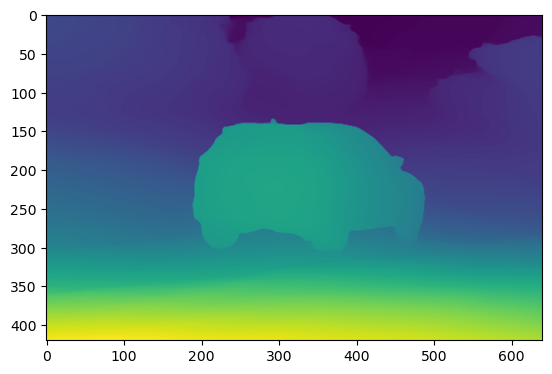

In [16]:
import matplotlib.pyplot as plt
plt.imshow(depth)

In [20]:
input_video_path = "driving.mp4"
output_video_path = "depth_output.avi"

cap = cv2.VideoCapture(input_video_path)

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
fourcc = cv2.VideoWriter_fourcc(*'XVID')


out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break 
        
    pil_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    depth = pipe(pil_image)["depth"]

    depth_np = np.array(depth)
    depth_rescaled = cv2.normalize(depth_np, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    depth_colormap = cv2.applyColorMap(depth_rescaled, cv2.COLORMAP_JET)

    cv2.imshow("Depth Estimation", depth_colormap)
    out.write(depth_colormap)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


cap.release()
out.release()
cv2.destroyAllWindows()

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
